# Performance Analysis

Analyses metrics from `load_test.py`: TTFT, throughput, latency percentiles.

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("metrics.csv")
df = df[df["error"].isna() | (df["error"] == "")]
print(f"Loaded {len(df)} successful requests")
df.head()

Loaded 90 successful requests


,prompt_type,concurrency,ttft,tpot,total_latency,tokens_generated,prompt_length,error
0,short,1,2.481886,4.460752,2.690129,12,14,NaN
1,short,1,2.137430,5.062376,2.370428,12,14,NaN
2,short,1,2.192758,4.997549,2.401177,12,14,NaN
3,long,1,2.219184,28.807120,4.443346,128,263,NaN
4,long,1,2.138615,29.510802,4.337395,128,263,NaN


## 1. TTFT by concurrency and prompt type

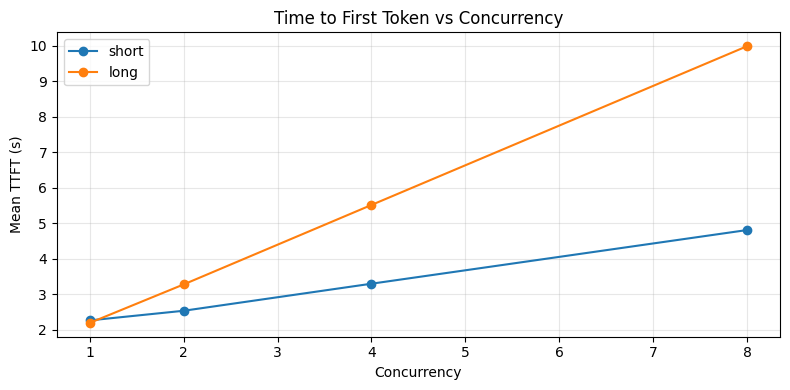

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
for ptype in df["prompt_type"].unique():
    sub = df[df["prompt_type"] == ptype]
    grouped = sub.groupby("concurrency")["ttft"].mean()
    ax.plot(grouped.index, grouped.values, marker="o", label=ptype)
ax.set_xlabel("Concurrency"); ax.set_ylabel("Mean TTFT (s)")
ax.set_title("Time to First Token vs Concurrency")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig("ttft_vs_concurrency.png", dpi=150); plt.show()

## 2. Throughput (tokens/s) vs concurrency

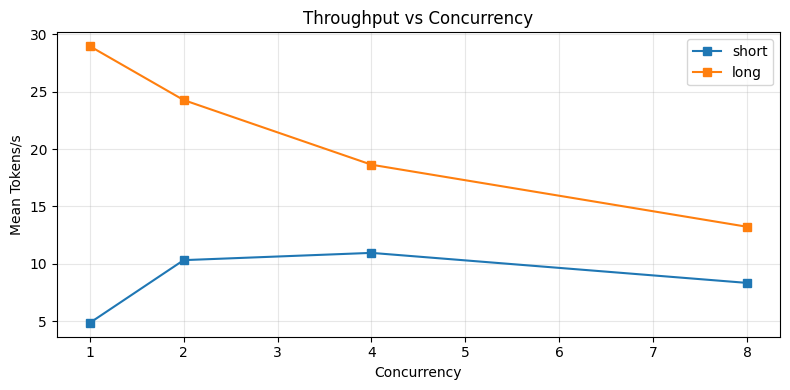

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
for ptype in df["prompt_type"].unique():
    sub = df[df["prompt_type"] == ptype]
    grouped = sub.groupby("concurrency")["tpot"].mean()
    ax.plot(grouped.index, grouped.values, marker="s", label=ptype)
ax.set_xlabel("Concurrency"); ax.set_ylabel("Mean Tokens/s")
ax.set_title("Throughput vs Concurrency")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig("tpot_vs_concurrency.png", dpi=150); plt.show()

## 3. Latency percentiles (P50 / P95 / P99)

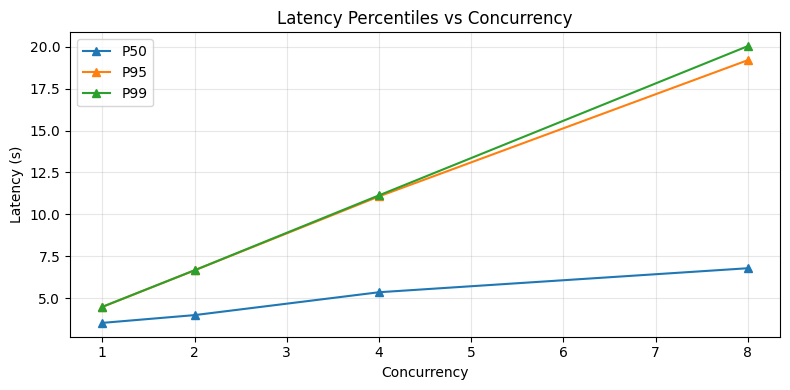

In [11]:
pcts = [50, 95, 99]
fig, ax = plt.subplots(figsize=(8, 4))
conc_levels = sorted(df["concurrency"].unique())
for p in pcts:
    vals = [np.percentile(df[df["concurrency"] == c]["total_latency"], p) for c in conc_levels]
    ax.plot(conc_levels, vals, marker="^", label=f"P{p}")
ax.set_xlabel("Concurrency"); ax.set_ylabel("Latency (s)")
ax.set_title("Latency Percentiles vs Concurrency")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig("latency_percentiles.png", dpi=150); plt.show()

## 4. Summary table

In [12]:
summary = df.groupby(["concurrency", "prompt_type"]).agg(
    ttft_mean=("ttft", "mean"), tpot_mean=("tpot", "mean"),
    lat_p50=("total_latency", lambda x: np.percentile(x, 50)),
    lat_p95=("total_latency", lambda x: np.percentile(x, 95)),
    lat_p99=("total_latency", lambda x: np.percentile(x, 99)),
    n=("total_latency", "count"),
).round(4)
summary

ttft_mean  tpot_mean  lat_p50  lat_p95  lat_p99   n
concurrency prompt_type                                                     
1           long            2.2001    28.9768   4.4433   4.4705   4.4730   3
            short           2.2707     4.8402   2.4012   2.6612   2.6844   3
2           long            3.2836    24.2769   5.4828   6.6545   6.6569   6
            short           2.5415    10.3139   3.1536   3.5900   3.6369   6
4           long            5.5210    18.6366   7.7238  11.1093  11.1373  12
            short           3.3036    10.9467   3.9375   5.5843   5.7104  12
8           long            9.9924    13.2226  12.2096  19.9973  20.0581  24
            short           4.8148     8.3267   5.4079   8.5649   8.6235  24

## Commentary

1. **TTFT increases with concurrency** - queuing adds latency.
2. **Per-request throughput stays roughly constant** - Ollama serialises generation.
3. **Long prompts have higher TTFT** - prompt-eval is proportional to input length.
4. **P95/P99 grows faster than P50** - tail latency dominated by queueing.
5. For latency-sensitive serving keep concurrency <= 2; for throughput use 4-8.